In [9]:
# Analysis of probe weight similarity across layers
# This notebook examines how similar learned probe weights are across different layers
# of a language model (Llama-3.2-3B-Instruct)

from pathlib import Path
import matplotlib.pyplot as plt
import joblib
from tqdm.notebook import tqdm_notebook as tqdm
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load all trained logistic regression probes from different layers
# Fix: Use path relative to notebook directory (go up one level from notebooks/ to obfuscated_activations/)
base = Path("../outputs/probes/logreg/input/meta-llama-Llama-3.2-3B-Instruct")

collate = []

# Collect the learned weight vectors (coefficients) from each layer's probe
for f in tqdm(base.glob("*.joblib")):
    collate.append(joblib.load(f)["model"].coef_)

0it [00:00, ?it/s]

In [10]:
def cosine_similarity_stats(n, d):
    """
    Compute the mean and standard deviation of cosine similarities 
    between n random vectors of dimension d.
    
    This establishes a baseline for what level of similarity would be expected
    by chance between random high-dimensional vectors. Used to compute z-scores
    for observed similarities.
    
    Parameters:
    -----------
    n : int
        Number of random vectors to generate
    d : int
        Dimension of each vector
    
    Returns:
    --------
    tuple : (mean, std)
        Mean and standard deviation of pairwise cosine similarities
    """
    # Generate n random vectors of dimension d
    vectors = np.random.randn(n, d)
    
    # Normalize vectors to unit length
    vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    
    # Compute pairwise cosine similarities (dot product of normalized vectors)
    cosine_similarities = vectors @ vectors.T
    
    # Extract upper triangular part (excluding diagonal)
    # to get unique pairs without self-similarities
    upper_triangle_indices = np.triu_indices(n, k=1)
    unique_similarities = cosine_similarities[upper_triangle_indices]
    
    # Compute mean and standard deviation
    mean = np.mean(unique_similarities)
    std = np.std(unique_similarities, ddof=1)  # ddof=1 for sample std
    
    return mean, std

# Compute baseline statistics for random 3072-dimensional vectors
# (matching the activation dimension of Llama-3.2-3B)
mean, std = cosine_similarity_stats(5000, 3072)

# Concatenate all probe weights into a single array
# Shape: (num_layers, activation_dim)
arr = np.concatenate(collate, axis=0)


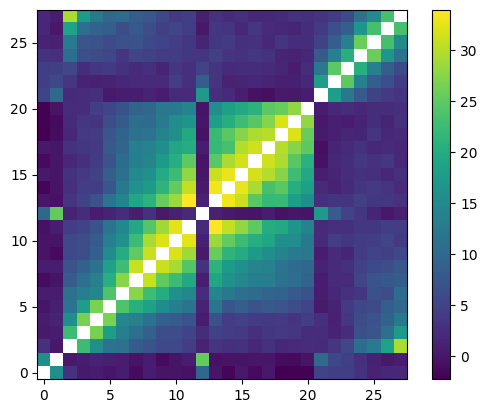

In [11]:
# Compute pairwise cosine similarities between all probe weight vectors
sims = cosine_similarity(arr)

# Convert raw similarities to z-scores using random baseline
# This shows how many standard deviations above/below chance each similarity is
z_scores = sims/std

# Set diagonal to NaN to prevent self-similarities (which are always 1.0)
# from distorting the colorscale
np.fill_diagonal(z_scores, np.nan)

# Visualize the similarity matrix
# Higher values (yellow) indicate probe weights that are more similar than expected by chance
# Lower values (purple) indicate dissimilar probe weights
plt.imshow(z_scores, origin="lower")
plt.colorbar()

In [12]:
# Compute the mean probe weight vector across all layers
mean_vect = arr.mean(axis=0)

# Calculate norms for cosine similarity computation
norm_v = np.linalg.norm(mean_vect)
norm_m = np.linalg.norm(arr, axis=1)

# Compute cosine similarity of each layer's probe to the mean probe
dot_product = arr @ mean_vect
similarities = dot_product / (norm_m * norm_v + 1e-9)

# Find the layer with minimum similarity to the mean
# This identifies which layer's probe is most "different" from the average
min_similarity = np.min(similarities)

# Convert to z-score to assess statistical significance
min_z_score = min_similarity/std

# Even the most dissimilar probe has a very high z-score (~14.6),
# indicating all probes are highly similar to each other
(min_similarity, min_z_score)

(0.26341248, 14.59521002373224)

## Conclusion

* There is significant mutual information between coefs. 
* The geometric similarity is not sufficient to use a single representative direction.